# Sentiment Analysis of Customer Service Conversations

**Course:** DI 725 - Transformers and Attention-Based Deep Networks  
**Student Number:** 2786028  
**Model:** RoBERTa-base (fine-tuning)  
**Task:** 3-class sentiment classification (positive, negative, neutral)

This notebook implements a complete pipeline for sentiment analysis on customer service conversations using a fine-tuned RoBERTa model. Key design decisions:

- **Metadata prepend:** Categorical features (issue area, complexity, product, agent level) are prepended as text to the conversation
- **Head+Tail truncation:** First 128 + last 382 tokens to capture both problem statement and resolution
- **Class-weighted loss:** To handle severe class imbalance (positive class ~1.7%)
- **Experiment tracking:** All experiments logged to Weights & Biases

## 1. Setup & Imports

In [1]:
!pip install transformers wandb scikit-learn -q

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import wandb
import warnings
warnings.filterwarnings('ignore')

# --- Reproducibility ---
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [3]:
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sceran to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Data Loading

In [4]:
# Update this for Google Colab
DATA_DIR = 'Assignment - 1 Dataset'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train set: {train_df.shape}")
print(f"Test set:  {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
train_df.head(2)

Train set: (970, 11)
Test set:  (30, 11)

Columns: ['issue_area', 'issue_category', 'issue_sub_category', 'issue_category_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'agent_experience_level_desc', 'conversation']


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...


## 3. Exploratory Data Analysis

In [5]:
# Missing values
print("=== Missing Values (Train) ===")
print(train_df.isnull().sum())
print(f"\nTotal missing: {train_df.isnull().sum().sum()}")

print("\n=== Missing Values (Test) ===")
print(test_df.isnull().sum())
print(f"\nTotal missing: {test_df.isnull().sum().sum()}")

=== Missing Values (Train) ===
issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64

Total missing: 0

=== Missing Values (Test) ===
issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64

Total missing: 0


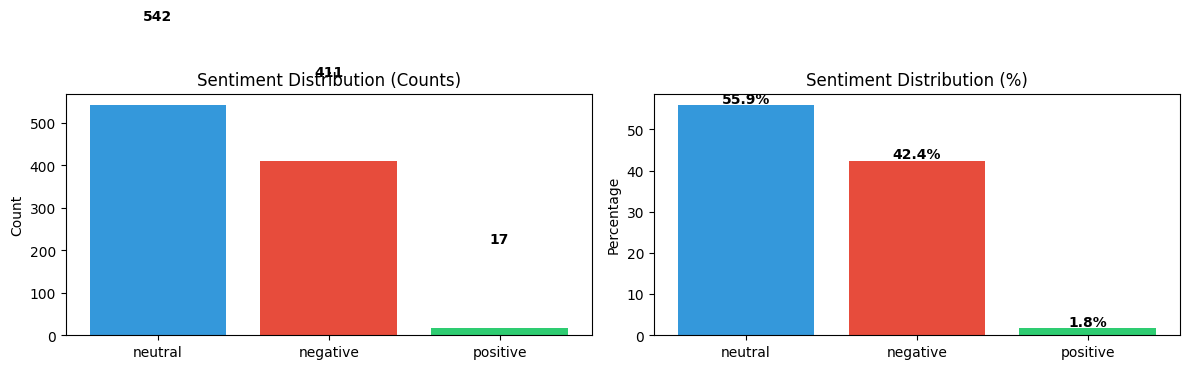


Class imbalance ratio (max/min): 31.9x


In [6]:
# Sentiment class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
sentiment_counts = train_df['customer_sentiment'].value_counts()
colors = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}
bar_colors = [colors[s] for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors)
axes[0].set_title('Sentiment Distribution (Counts)')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
    axes[0].text(i, val + 200, str(val), ha='center', fontweight='bold')

# Percentages
sentiment_pct = (sentiment_counts / len(train_df) * 100).round(1)
axes[1].bar(sentiment_pct.index, sentiment_pct.values, color=bar_colors)
axes[1].set_title('Sentiment Distribution (%)')
axes[1].set_ylabel('Percentage')
for i, (idx, val) in enumerate(zip(sentiment_pct.index, sentiment_pct.values)):
    axes[1].text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio (max/min): {sentiment_counts.max() / sentiment_counts.min():.1f}x")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (582 > 512). Running this sequence through the model will result in indexing errors


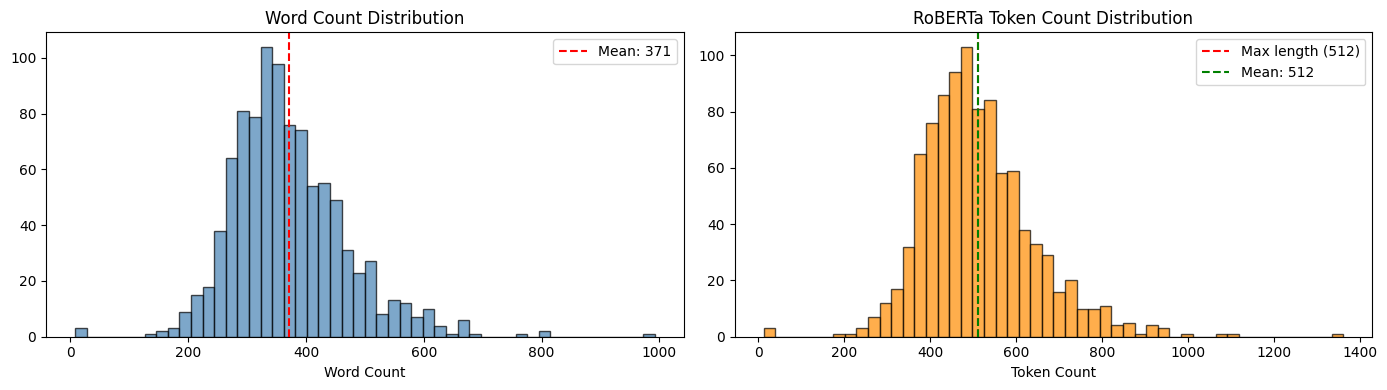

Conversations exceeding 512 tokens: 44.3%
Token count stats:
count     970.0
mean      512.0
std       132.0
min        13.0
25%       425.0
50%       494.0
75%       582.0
max      1362.0
Name: token_count, dtype: float64


In [7]:
# Conversation length analysis
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

train_df['word_count'] = train_df['conversation'].apply(lambda x: len(str(x).split()))
train_df['token_count'] = train_df['conversation'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=False))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=train_df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {train_df['word_count'].mean():.0f}")
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].legend()

axes[1].hist(train_df['token_count'], bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axvline(x=512, color='red', linestyle='--', label='Max length (512)')
axes[1].axvline(x=train_df['token_count'].mean(), color='green', linestyle='--', label=f"Mean: {train_df['token_count'].mean():.0f}")
axes[1].set_title('RoBERTa Token Count Distribution')
axes[1].set_xlabel('Token Count')
axes[1].legend()

plt.tight_layout()
plt.show()

over_512 = (train_df['token_count'] > 512).mean() * 100
print(f"Conversations exceeding 512 tokens: {over_512:.1f}%")
print(f"Token count stats:\n{train_df['token_count'].describe().round(0)}")

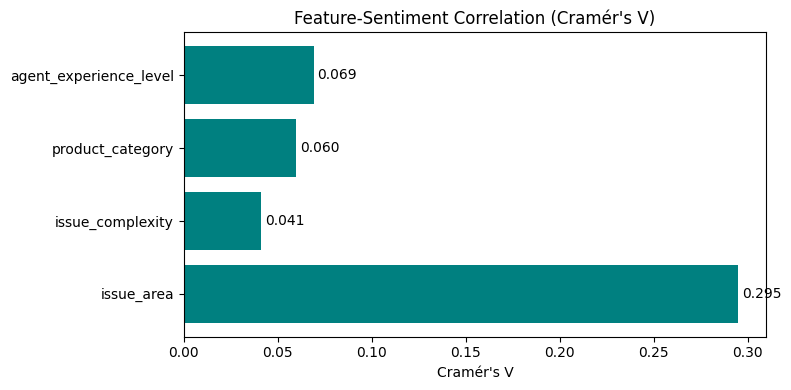

In [8]:
# Feature-sentiment correlation using Cramer's V
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

cat_features = ['issue_area', 'issue_complexity', 'product_category', 'agent_experience_level']
correlations = {feat: cramers_v(train_df[feat], train_df['customer_sentiment']) for feat in cat_features}

plt.figure(figsize=(8, 4))
bars = plt.barh(list(correlations.keys()), list(correlations.values()), color='teal')
plt.xlabel("Cramér's V")
plt.title("Feature-Sentiment Correlation (Cramér's V)")
for bar, val in zip(bars, correlations.values()):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

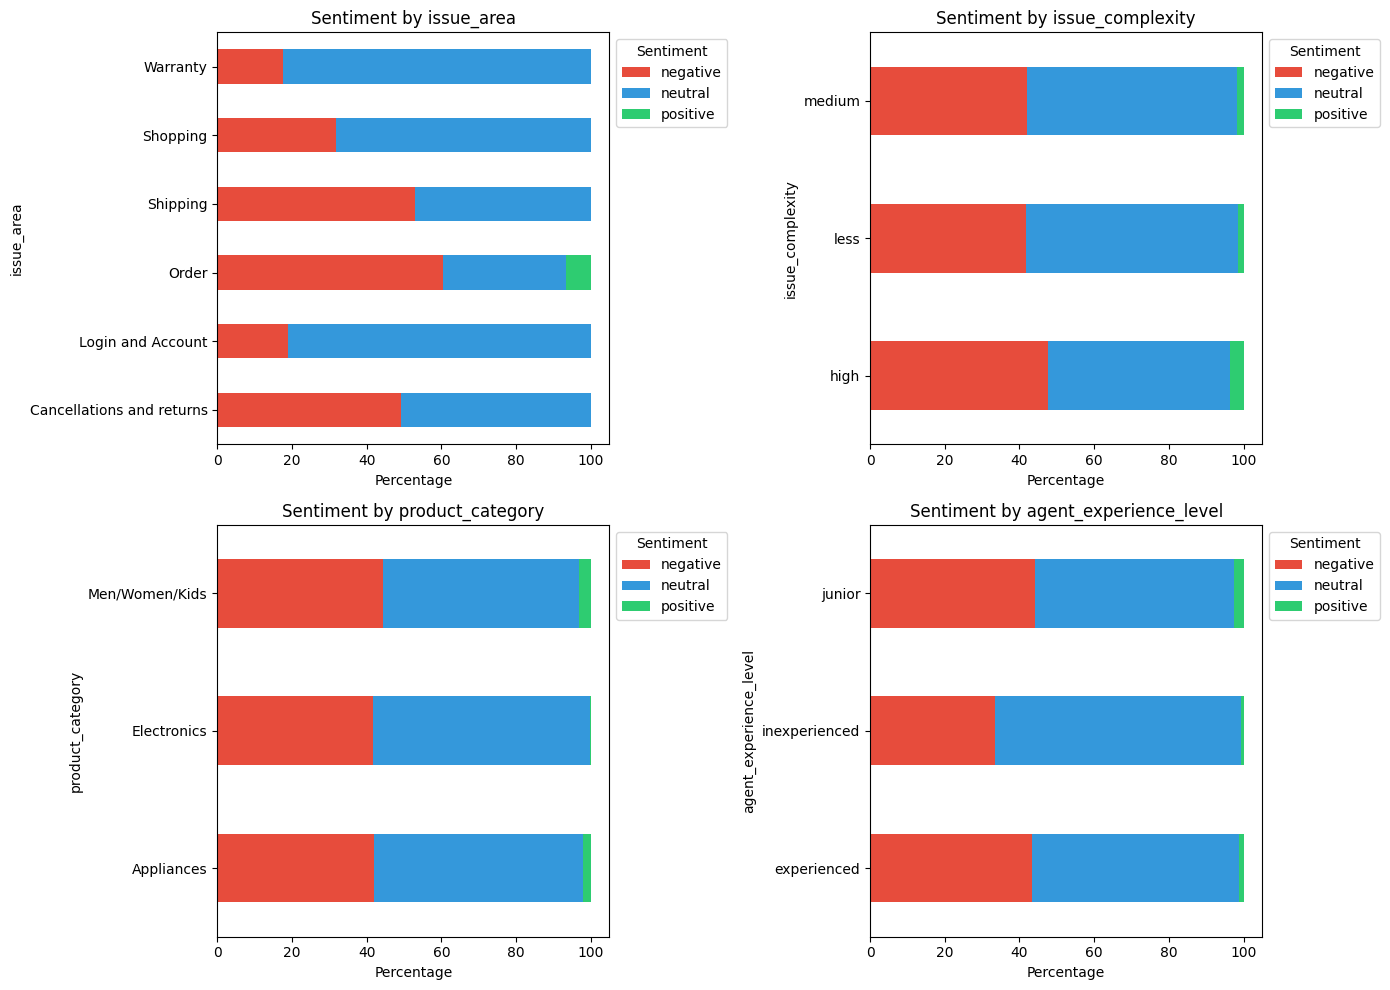

In [9]:
# Cross-tabulation: sentiment vs key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), cat_features):
    ct = pd.crosstab(train_df[feat], train_df['customer_sentiment'], normalize='index') * 100
    ct[['negative', 'neutral', 'positive']].plot(
        kind='barh', stacked=True, ax=ax,
        color=['#e74c3c', '#3498db', '#2ecc71']
    )
    ax.set_title(f'Sentiment by {feat}')
    ax.set_xlabel('Percentage')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

### EDA Findings

1. **Class imbalance:** The dataset has severe imbalance — positive class is extremely underrepresented (~1.7%), while negative and neutral dominate. This justifies using **class-weighted loss** during training.

2. **Conversation length:** ~35% of conversations exceed the 512 token limit of RoBERTa. A **head+tail truncation** strategy (first 128 + last 382 tokens) is used to preserve both the problem statement and resolution/sentiment cues.

3. **Feature correlations:** Cramér's V analysis shows weak but non-zero correlations between categorical features (issue_area, issue_complexity, product_category, agent_experience_level) and sentiment. These features are **prepended as text metadata** to the conversation to provide additional context to the model.

4. **No missing values** detected in either train or test sets.

## 4. Preprocessing & Tokenization

In [10]:
# Preprocessing: metadata prepend + whitespace cleanup
def preprocess_text(row, use_metadata=True):
    conversation = ' '.join(str(row['conversation']).split())  # normalize whitespace
    if use_metadata:
        meta = (
            f"Area: {row['issue_area']} | "
            f"Complexity: {row['issue_complexity']} | "
            f"Product: {row['product_category']} | "
            f"Agent: {row['agent_experience_level']} | "
        )
        return meta + conversation
    return conversation

# Label encoding
LABEL_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)

train_df['label'] = train_df['customer_sentiment'].map(LABEL_MAP)
test_df['label'] = test_df['customer_sentiment'].map(LABEL_MAP)

# Class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=train_df['label'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights: {dict(zip(LABEL_MAP.keys(), class_weights.round(3)))}")

Class weights: {'negative': np.float64(0.787), 'neutral': np.float64(0.597), 'positive': np.float64(19.02)}


In [11]:
# Head+Tail tokenization
MAX_LEN = 512
HEAD_LEN = 128
TAIL_LEN = MAX_LEN - HEAD_LEN - 2  # 382, reserve 2 for <s> and </s>

def head_tail_tokenize(text, tokenizer, head_only=False):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    if len(tokens) <= MAX_LEN - 2:
        tokens = tokens[:MAX_LEN - 2]
    elif head_only:
        tokens = tokens[:MAX_LEN - 2]
    else:
        tokens = tokens[:HEAD_LEN] + tokens[-TAIL_LEN:]

    input_ids = [tokenizer.cls_token_id] + tokens + [tokenizer.sep_token_id]
    attention_mask = [1] * len(input_ids)

    # Pad to MAX_LEN
    pad_len = MAX_LEN - len(input_ids)
    input_ids += [tokenizer.pad_token_id] * pad_len
    attention_mask += [0] * pad_len

    return input_ids, attention_mask

# PyTorch Dataset
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, head_only=False):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.head_only = head_only

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = head_tail_tokenize(
            self.texts[idx], self.tokenizer, self.head_only
        )
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [12]:
# Train/validation stratified split (80/20)
train_texts_meta = train_df.apply(lambda r: preprocess_text(r, use_metadata=True), axis=1).tolist()
train_texts_nometa = train_df.apply(lambda r: preprocess_text(r, use_metadata=False), axis=1).tolist()
train_labels = train_df['label'].values

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels)),
    test_size=0.2,
    stratify=train_labels,
    random_state=SEED
)

print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
print(f"\nTrain label distribution:")
print(pd.Series(train_labels[train_idx]).value_counts().sort_index().rename(ID2LABEL))
print(f"\nVal label distribution:")
print(pd.Series(train_labels[val_idx]).value_counts().sort_index().rename(ID2LABEL))

Train size: 776, Val size: 194

Train label distribution:
negative    329
neutral     434
positive     13
Name: count, dtype: int64

Val label distribution:
negative     82
neutral     108
positive      4
Name: count, dtype: int64


## 5. Training Pipeline

In [13]:
def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    return {
        'loss': avg_loss,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'preds': all_preds,
        'labels': all_labels
    }

In [14]:
def run_experiment(exp_name, texts, labels, train_idx, val_idx, tokenizer,
                   lr=2e-5, batch_size=16, epochs=10, head_only=False, patience=2):
    set_seed(SEED)
    print(f"\n{'='*60}")
    print(f"Experiment: {exp_name}")
    print(f"LR={lr}, Batch={batch_size}, HeadOnly={head_only}")
    print(f"{'='*60}")

    # Datasets & DataLoaders
    train_texts = [texts[i] for i in train_idx]
    val_texts = [texts[i] for i in val_idx]
    train_labs = labels[train_idx]
    val_labs = labels[val_idx]

    train_dataset = SentimentDataset(train_texts, train_labs, tokenizer, head_only)
    val_dataset = SentimentDataset(val_texts, val_labs, tokenizer, head_only)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Model
    model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=NUM_LABELS)
    model.to(device)

    # Optimizer, scheduler, loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

    # WANDB
    run = wandb.init(
        project='sentiment-analysis-transformer',
        name=exp_name,
        config={'lr': lr, 'batch_size': batch_size, 'epochs': epochs,
                'head_only': head_only, 'max_len': MAX_LEN,
                'head_len': HEAD_LEN, 'model': 'roberta-base'}
    )

    # Training loop
    best_f1 = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, batch_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        val_metrics = evaluate(model, val_loader, device)

        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | Val F1-macro: {val_metrics['f1_macro']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f}")

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1_macro': val_metrics['f1_macro'],
            'val_f1_weighted': val_metrics['f1_weighted'],
            'learning_rate': current_lr
        })

        # Early stopping on val F1-macro
        if val_metrics['f1_macro'] > best_f1:
            best_f1 = val_metrics['f1_macro']
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, f'best_model_{exp_name}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    wandb.log({'best_val_f1_macro': best_f1})
    wandb.finish()

    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest Val F1-macro: {best_f1:.4f}")
    return model, best_f1

## 6. Experiments

| # | Change | LR | Batch | Truncation | Metadata |
|---|--------|----|-------|------------|----------|
| 1 | Baseline | 2e-5 | 16 | head-only | Yes |
| 2 | Truncation | 2e-5 | 16 | head+tail | Yes |
| 3 | LR low | 1e-5 | 16 | best | Yes |
| 4 | LR high | 5e-5 | 16 | best | Yes |
| 5 | Batch size | best LR | 8 | best | Yes |
| 6 | No metadata (ablation) | best LR | best batch | best | No |

Each experiment builds on the best result from the previous one (greedy search).

In [15]:
results = {}

# Experiment 1: Baseline (head-only, metadata, lr=2e-5, batch=16)
model_1, f1_1 = run_experiment(
    'exp1_baseline', train_texts_meta, train_labels, train_idx, val_idx,
    tokenizer, lr=2e-5, batch_size=16, head_only=True
)
results['exp1_baseline'] = f1_1


Experiment: exp1_baseline
LR=2e-05, Batch=16, HeadOnly=True


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 1.0465 | Val Loss: 1.2878 | Val F1-macro: 0.2559 | Val Acc: 0.5670
Epoch 2/10 | Train Loss: 0.8095 | Val Loss: 0.7678 | Val F1-macro: 0.5761 | Val Acc: 0.8608
Epoch 3/10 | Train Loss: 0.5255 | Val Loss: 0.8718 | Val F1-macro: 0.6034 | Val Acc: 0.8969
Epoch 4/10 | Train Loss: 0.3557 | Val Loss: 1.0345 | Val F1-macro: 0.6181 | Val Acc: 0.9175
Epoch 5/10 | Train Loss: 0.2485 | Val Loss: 1.1575 | Val F1-macro: 0.5948 | Val Acc: 0.8814
Epoch 6/10 | Train Loss: 0.1768 | Val Loss: 1.0441 | Val F1-macro: 0.6722 | Val Acc: 0.8814
Epoch 7/10 | Train Loss: 0.1914 | Val Loss: 0.6714 | Val F1-macro: 0.7043 | Val Acc: 0.9021
Epoch 8/10 | Train Loss: 0.0701 | Val Loss: 0.9084 | Val F1-macro: 0.6093 | Val Acc: 0.9021
Epoch 9/10 | Train Loss: 0.0280 | Val Loss: 0.7958 | Val F1-macro: 0.6094 | Val Acc: 0.9021
Early stopping at epoch 9


best_val_f1_macro,▁
epoch,▁▂▃▄▅▅▆▇█
learning_rate,█▇▆▅▅▄▃▂▁
train_loss,█▆▄▃▃▂▂▁▁
val_accuracy,▁▇██▇▇███
val_f1_macro,▁▆▆▇▆▇█▇▇
val_f1_weighted,▁▇███████
val_loss,█▂▃▅▇▅▁▄▂
best_val_f1_macro,0.70426
epoch,9
learning_rate,0.0



Best Val F1-macro: 0.7043


In [16]:
# Experiment 2: Head+Tail truncation
model_2, f1_2 = run_experiment(
    'exp2_head_tail', train_texts_meta, train_labels, train_idx, val_idx,
    tokenizer, lr=2e-5, batch_size=16, head_only=False
)
results['exp2_head_tail'] = f1_2

# Determine best truncation
best_head_only = f1_1 > f1_2
print(f"\nBest truncation: {'head-only' if best_head_only else 'head+tail'}")


Experiment: exp2_head_tail
LR=2e-05, Batch=16, HeadOnly=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 1.0530 | Val Loss: 1.2762 | Val F1-macro: 0.2384 | Val Acc: 0.5567
Epoch 2/10 | Train Loss: 0.8295 | Val Loss: 0.8574 | Val F1-macro: 0.5425 | Val Acc: 0.8196
Epoch 3/10 | Train Loss: 0.5776 | Val Loss: 0.9155 | Val F1-macro: 0.5886 | Val Acc: 0.8763
Epoch 4/10 | Train Loss: 0.3690 | Val Loss: 0.7780 | Val F1-macro: 0.6217 | Val Acc: 0.9227
Epoch 5/10 | Train Loss: 0.1929 | Val Loss: 0.4486 | Val F1-macro: 0.6869 | Val Acc: 0.9021
Epoch 6/10 | Train Loss: 0.1199 | Val Loss: 0.2737 | Val F1-macro: 0.8393 | Val Acc: 0.9175
Epoch 7/10 | Train Loss: 0.0602 | Val Loss: 0.2914 | Val F1-macro: 0.9219 | Val Acc: 0.9381
Epoch 8/10 | Train Loss: 0.0226 | Val Loss: 0.3363 | Val F1-macro: 0.9115 | Val Acc: 0.9381
Epoch 9/10 | Train Loss: 0.0131 | Val Loss: 0.2964 | Val F1-macro: 0.9606 | Val Acc: 0.9433
Epoch 10/10 | Train Loss: 0.0117 | Val Loss: 0.2903 | Val F1-macro: 0.9606 | Val Acc: 0.9433


best_val_f1_macro,▁
epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,█▇▆▆▅▄▃▃▂▁
train_loss,█▆▅▃▂▂▁▁▁▁
val_accuracy,▁▆▇█▇█████
val_f1_macro,▁▄▄▅▅▇████
val_f1_weighted,▁▆▇█▇█████
val_loss,█▅▅▅▂▁▁▁▁▁
best_val_f1_macro,0.96061
epoch,10
learning_rate,0



Best Val F1-macro: 0.9606

Best truncation: head+tail


In [17]:
# Experiment 3: Lower LR (1e-5)
model_3, f1_3 = run_experiment(
    'exp3_lr_1e5', train_texts_meta, train_labels, train_idx, val_idx,
    tokenizer, lr=1e-5, batch_size=16, head_only=best_head_only
)
results['exp3_lr_1e5'] = f1_3


Experiment: exp3_lr_1e5
LR=1e-05, Batch=16, HeadOnly=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 1.0805 | Val Loss: 1.0696 | Val F1-macro: 0.5052 | Val Acc: 0.7577
Epoch 2/10 | Train Loss: 1.0016 | Val Loss: 0.9005 | Val F1-macro: 0.5566 | Val Acc: 0.8299
Epoch 3/10 | Train Loss: 0.6782 | Val Loss: 0.9135 | Val F1-macro: 0.6041 | Val Acc: 0.8969
Epoch 4/10 | Train Loss: 0.4777 | Val Loss: 0.7561 | Val F1-macro: 0.6146 | Val Acc: 0.9124
Epoch 5/10 | Train Loss: 0.3342 | Val Loss: 0.7078 | Val F1-macro: 0.6727 | Val Acc: 0.8814
Epoch 6/10 | Train Loss: 0.3880 | Val Loss: 0.4982 | Val F1-macro: 0.6314 | Val Acc: 0.7938
Epoch 7/10 | Train Loss: 0.2758 | Val Loss: 0.6629 | Val F1-macro: 0.6671 | Val Acc: 0.8814
Early stopping at epoch 7


best_val_f1_macro,▁
epoch,▁▂▃▅▆▇█
learning_rate,█▇▆▅▃▂▁
train_loss,█▇▅▃▂▂▁
val_accuracy,▁▄▇█▇▃▇
val_f1_macro,▁▃▅▆█▆█
val_f1_weighted,▁▄▇█▇▅▇
val_loss,█▆▆▄▄▁▃
best_val_f1_macro,0.6727
epoch,7
learning_rate,0.0



Best Val F1-macro: 0.6727


In [18]:
# Experiment 4: Higher LR (5e-5)
model_4, f1_4 = run_experiment(
    'exp4_lr_5e5', train_texts_meta, train_labels, train_idx, val_idx,
    tokenizer, lr=5e-5, batch_size=16, head_only=best_head_only
)
results['exp4_lr_5e5'] = f1_4

# Determine best LR
lr_results = {2e-5: max(f1_1, f1_2), 1e-5: f1_3, 5e-5: f1_4}
best_lr = max(lr_results, key=lr_results.get)
print(f"\nBest LR: {best_lr}")


Experiment: exp4_lr_5e5
LR=5e-05, Batch=16, HeadOnly=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 1.0731 | Val Loss: 1.2381 | Val F1-macro: 0.5374 | Val Acc: 0.7990
Epoch 2/10 | Train Loss: 0.8401 | Val Loss: 0.7457 | Val F1-macro: 0.5814 | Val Acc: 0.8660
Epoch 3/10 | Train Loss: 0.5650 | Val Loss: 0.8659 | Val F1-macro: 0.5900 | Val Acc: 0.8711
Epoch 4/10 | Train Loss: 0.3034 | Val Loss: 0.5391 | Val F1-macro: 0.6076 | Val Acc: 0.9021
Epoch 5/10 | Train Loss: 0.2274 | Val Loss: 1.2715 | Val F1-macro: 0.6147 | Val Acc: 0.9072
Epoch 6/10 | Train Loss: 0.0915 | Val Loss: 1.1386 | Val F1-macro: 0.7014 | Val Acc: 0.9124
Epoch 7/10 | Train Loss: 0.0127 | Val Loss: 0.3873 | Val F1-macro: 0.8206 | Val Acc: 0.9124
Epoch 8/10 | Train Loss: 0.0013 | Val Loss: 0.9950 | Val F1-macro: 0.7077 | Val Acc: 0.9072
Epoch 9/10 | Train Loss: 0.0009 | Val Loss: 1.1960 | Val F1-macro: 0.7288 | Val Acc: 0.9175
Early stopping at epoch 9


best_val_f1_macro,▁
epoch,▁▂▃▄▅▅▆▇█
learning_rate,█▇▆▅▅▄▃▂▁
train_loss,█▆▅▃▂▂▁▁▁
val_accuracy,▁▅▅▇▇██▇█
val_f1_macro,▁▂▂▃▃▅█▅▆
val_f1_weighted,▁▅▅▇▇██▇█
val_loss,█▄▅▂█▇▁▆▇
best_val_f1_macro,0.82059
epoch,9
learning_rate,1e-05



Best Val F1-macro: 0.8206

Best LR: 2e-05


In [19]:
# Experiment 5: Smaller batch size (8)
model_5, f1_5 = run_experiment(
    'exp5_batch8', train_texts_meta, train_labels, train_idx, val_idx,
    tokenizer, lr=best_lr, batch_size=8, head_only=best_head_only
)
results['exp5_batch8'] = f1_5

# Determine best batch size
best_batch = 8 if f1_5 > lr_results[best_lr] else 16
print(f"\nBest batch size: {best_batch}")


Experiment: exp5_batch8
LR=2e-05, Batch=8, HeadOnly=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 0.9991 | Val Loss: 0.8452 | Val F1-macro: 0.5604 | Val Acc: 0.8351
Epoch 2/10 | Train Loss: 0.6499 | Val Loss: 0.7254 | Val F1-macro: 0.5970 | Val Acc: 0.8866
Epoch 3/10 | Train Loss: 0.6221 | Val Loss: 0.9485 | Val F1-macro: 0.6003 | Val Acc: 0.8918
Epoch 4/10 | Train Loss: 0.5382 | Val Loss: 0.9179 | Val F1-macro: 0.6180 | Val Acc: 0.9175
Epoch 5/10 | Train Loss: 0.3002 | Val Loss: 0.8273 | Val F1-macro: 0.6215 | Val Acc: 0.9227
Epoch 6/10 | Train Loss: 0.1951 | Val Loss: 0.7282 | Val F1-macro: 0.6978 | Val Acc: 0.9072
Epoch 7/10 | Train Loss: 0.1142 | Val Loss: 0.7236 | Val F1-macro: 0.7325 | Val Acc: 0.9227
Epoch 8/10 | Train Loss: 0.0272 | Val Loss: 0.6210 | Val F1-macro: 0.7635 | Val Acc: 0.9381
Epoch 9/10 | Train Loss: 0.0163 | Val Loss: 0.3842 | Val F1-macro: 0.8779 | Val Acc: 0.9381
Epoch 10/10 | Train Loss: 0.0085 | Val Loss: 0.3980 | Val F1-macro: 0.8483 | Val Acc: 0.9330


best_val_f1_macro,▁
epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,█▇▆▆▅▄▃▃▂▁
train_loss,█▆▅▅▃▂▂▁▁▁
val_accuracy,▁▅▅▇▇▆▇███
val_f1_macro,▁▂▂▂▂▄▅▅█▇
val_f1_weighted,▁▄▅▆▆▆▇███
val_loss,▇▅██▆▅▅▄▁▁
best_val_f1_macro,0.87789
epoch,10
learning_rate,0



Best Val F1-macro: 0.8779

Best batch size: 16


In [20]:
# Experiment 6: Ablation — no metadata
model_6, f1_6 = run_experiment(
    'exp6_no_metadata', train_texts_nometa, train_labels, train_idx, val_idx,
    tokenizer, lr=best_lr, batch_size=best_batch, head_only=best_head_only
)
results['exp6_no_metadata'] = f1_6


Experiment: exp6_no_metadata
LR=2e-05, Batch=16, HeadOnly=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Train Loss: 1.0484 | Val Loss: 1.3098 | Val F1-macro: 0.2472 | Val Acc: 0.5619
Epoch 2/10 | Train Loss: 0.8564 | Val Loss: 0.7285 | Val F1-macro: 0.5804 | Val Acc: 0.8660
Epoch 3/10 | Train Loss: 0.5542 | Val Loss: 0.8861 | Val F1-macro: 0.6004 | Val Acc: 0.8918
Epoch 4/10 | Train Loss: 0.3387 | Val Loss: 0.9285 | Val F1-macro: 0.6166 | Val Acc: 0.9124
Epoch 5/10 | Train Loss: 0.2069 | Val Loss: 0.8921 | Val F1-macro: 0.6181 | Val Acc: 0.9175
Epoch 6/10 | Train Loss: 0.1749 | Val Loss: 0.4454 | Val F1-macro: 0.7604 | Val Acc: 0.9072
Epoch 7/10 | Train Loss: 0.0675 | Val Loss: 0.6700 | Val F1-macro: 0.7255 | Val Acc: 0.9124
Epoch 8/10 | Train Loss: 0.0202 | Val Loss: 0.6844 | Val F1-macro: 0.7291 | Val Acc: 0.9175
Early stopping at epoch 8


best_val_f1_macro,▁
epoch,▁▂▃▄▅▆▇█
learning_rate,█▇▆▅▄▃▂▁
train_loss,█▇▅▃▂▂▁▁
val_accuracy,▁▇▇█████
val_f1_macro,▁▆▆▆▆███
val_f1_weighted,▁▇██████
val_loss,█▃▅▅▅▁▃▃
best_val_f1_macro,0.76038
epoch,8
learning_rate,0.0



Best Val F1-macro: 0.7604


In [21]:
# Experiment summary
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
for name, f1 in results.items():
    print(f"{name:25s} | Val F1-macro: {f1:.4f}")
best_exp = max(results, key=results.get)
print(f"\nBest experiment: {best_exp} (F1-macro: {results[best_exp]:.4f})")


EXPERIMENT SUMMARY
exp1_baseline             | Val F1-macro: 0.7043
exp2_head_tail            | Val F1-macro: 0.9606
exp3_lr_1e5               | Val F1-macro: 0.6727
exp4_lr_5e5               | Val F1-macro: 0.8206
exp5_batch8               | Val F1-macro: 0.8779
exp6_no_metadata          | Val F1-macro: 0.7604

Best experiment: exp2_head_tail (F1-macro: 0.9606)


## 7. Test Evaluation

In [22]:
# Load best model and evaluate on test set
best_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=NUM_LABELS)
best_model.load_state_dict(torch.load(f'best_model_{best_exp}.pt'))
best_model.to(device)

# Determine test preprocessing based on best experiment
use_meta_test = 'no_metadata' not in best_exp
test_texts = test_df.apply(lambda r: preprocess_text(r, use_metadata=use_meta_test), axis=1).tolist()
test_labels = test_df['label'].values

test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, head_only=best_head_only)
test_loader = DataLoader(test_dataset, batch_size=16)

test_metrics = evaluate(best_model, test_loader, device)

print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"F1-macro:    {test_metrics['f1_macro']:.4f}")
print(f"F1-weighted: {test_metrics['f1_weighted']:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_metrics['labels'], test_metrics['preds'],
                            target_names=['negative', 'neutral', 'positive']))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TEST SET RESULTS
Accuracy:    0.8333
F1-macro:    0.8379
F1-weighted: 0.8379

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89        10
     neutral       0.69      0.90      0.78        10
    positive       0.89      0.80      0.84        10

    accuracy                           0.83        30
   macro avg       0.86      0.83      0.84        30
weighted avg       0.86      0.83      0.84        30



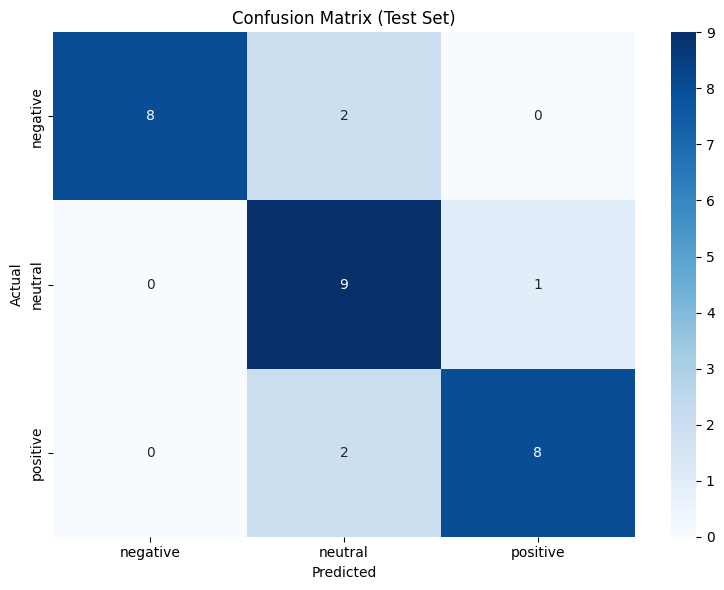

In [23]:
# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

In [24]:
# Log test results to WANDB
run = wandb.init(project='sentiment-analysis-transformer', name='test_evaluation')
wandb.log({
    'test_accuracy': test_metrics['accuracy'],
    'test_f1_macro': test_metrics['f1_macro'],
    'test_f1_weighted': test_metrics['f1_weighted']
})
wandb.log({'confusion_matrix': wandb.plot.confusion_matrix(
    y_true=test_metrics['labels'], preds=test_metrics['preds'],
    class_names=['negative', 'neutral', 'positive']
)})
wandb.finish()
print("Test results logged to WANDB.")

test_accuracy,▁
test_f1_macro,▁
test_f1_weighted,▁
test_accuracy,0.83333
test_f1_macro,0.83787
test_f1_weighted,0.83787


Test results logged to WANDB.
